## Palm Movement Detection using Optical Flow

This lab is part of [AI for Beginners Curriculum](http://aka.ms/ai-beginners).

Consider [this video](palm-movement.mp4), in which a person's palm moves left/right/up/down on the stable background.

<img src="../images/palm-movement.png" width="30%" alt="Palm Movement Frame"/>

**Your goal** would be to use Optical Flow to determine, which parts of video contain up/down/left/right movements. 

Start by getting video frames as described in the lecture:

Total frames: 242
(360, 640)


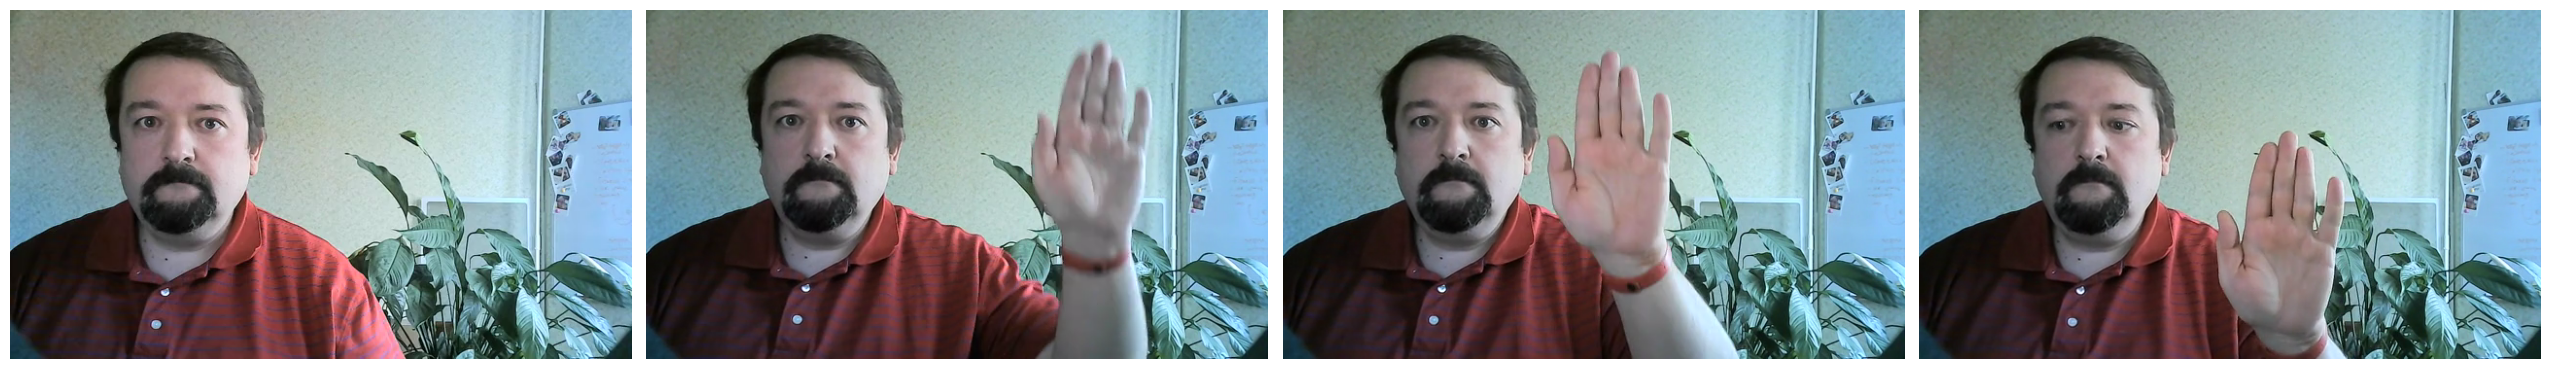

In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def display_images(l,titles=None,fontsize=12):
    n=len(l)
    fig,ax = plt.subplots(1,n)
    for i,im in enumerate(l):
        ax[i].imshow(im)
        ax[i].axis('off')
        if titles is not None:
            ax[i].set_title(titles[i],fontsize=fontsize)
    fig.set_size_inches(fig.get_size_inches()*n)
    plt.tight_layout()
    plt.show()

# Code here
vid = cv2.VideoCapture('palm-movement.mp4')

c = 0
frames = []
bwframes= []
while vid.isOpened():
    ret, frame = vid.read()
    if not ret:
        break
    frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    bwframes.append(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY))
    c+=1
vid.release()
print(f"Total frames: {c}")
print(bwframes[0].shape)
display_images(frames[::80])

Now, calculate dense optical flow frames as described in the lecture, and convert dense optical flow to polar coordinates: 

(360, 640, 2)


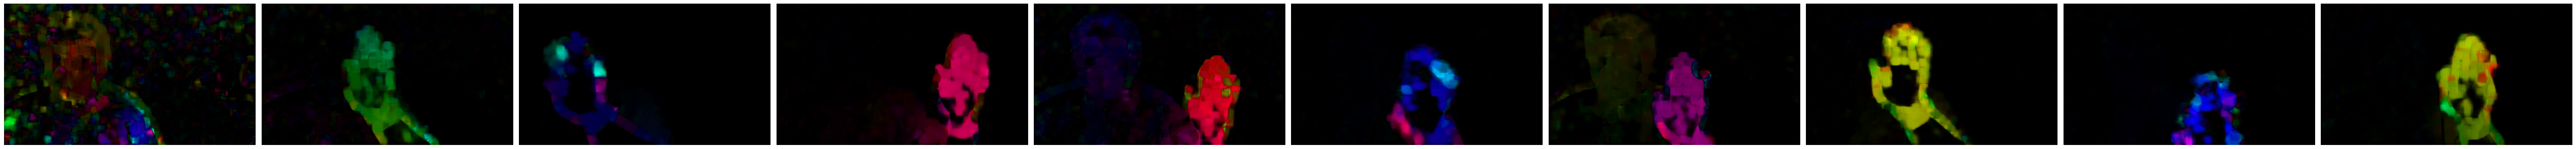

In [10]:
# Code here
flows = [cv2.calcOpticalFlowFarneback(f1, f2, None, 0.5, 3, 15, 3, 5, 1.2, 0) 
         for f1,f2 in zip(bwframes[:-1],bwframes[1:])]
print(flows[0].shape)
# print(flows[0][...,0].shape)

def flow_to_hsv(flow):
    hsvImg = np.zeros((flow.shape[0],flow.shape[1],3),dtype=np.uint8)
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    hsvImg[..., 0] = 0.5 * ang * 180 / np.pi
    hsvImg[..., 1] = 255
    hsvImg[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    return cv2.cvtColor(hsvImg, cv2.COLOR_HSV2BGR)

# start = sub[0]
# stop = sub[-1]
# print(start,stop)

frms = [flow_to_hsv(x) for x in flows[0:-1]]
display_images(frms[::25])

Build histogram of directions for each of the optical flow frame. A histogram shows how many vectors fall under certain bin, and it should separate out different directions of movement on the frame.

> You may also want to zero out all vectors whose magnitude is below certain threshold. This will get rid of small extra movements in the video, such as eyes and head.

Plot the histograms for some of the frames.

Motion Type: Up, Frames Count: 41


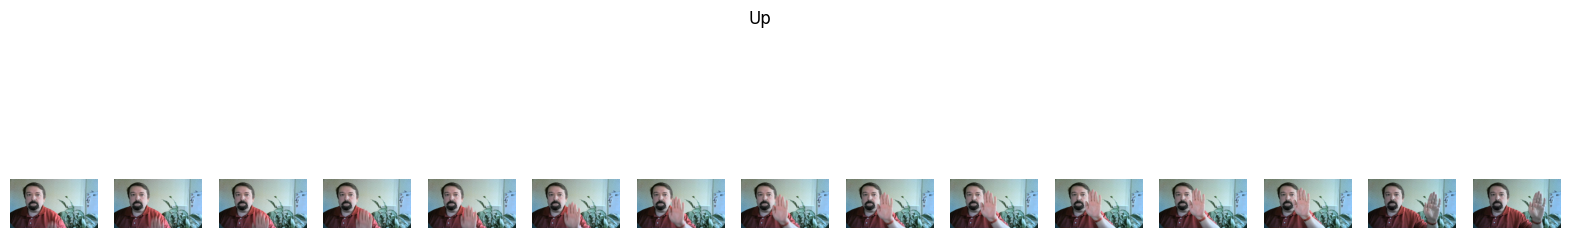

Motion Type: Down, Frames Count: 34


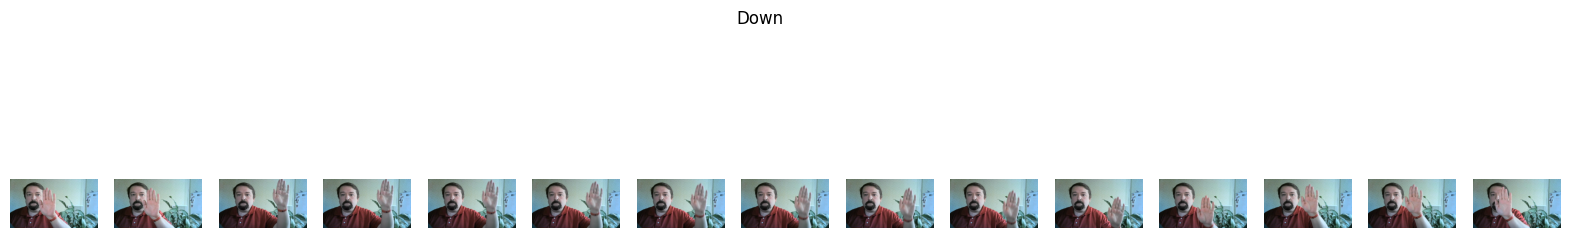

Motion Type: Left, Frames Count: 93


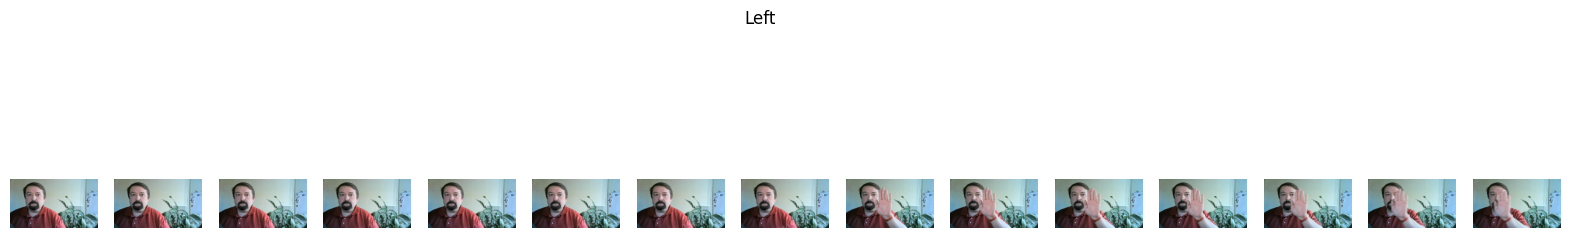

Motion Type: Right, Frames Count: 73


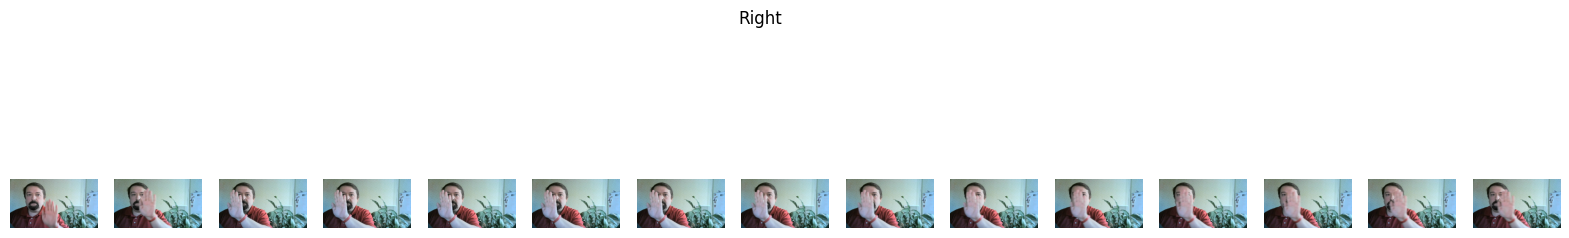

In [11]:
# Code here

import numpy as np
import os

def filter_optical_flow(flow, threshold=1.0):
    """
    过滤光流数据，将幅度小于 threshold 的光流设为 0。
    
    参数:
    - flow: 光流数组，形状 (H, W, 2)，包含 x, y 方向的光流。
    - threshold: 低于该值的光流设为 0。
    
    返回:
    - 过滤后的光流（副本，不修改原数据）
    """
    # 创建 flow 的副本
    flow_copy = np.copy(flow)
    
    # 提取 x 和 y 分量
    flow_x, flow_y = flow_copy[..., 0], flow_copy[..., 1]  
    
    # 计算光流幅度
    magnitude = np.sqrt(flow_x**2 + flow_y**2)  
    
    # 设置幅度低于 threshold 的光流为 0
    flow_copy[magnitude < threshold] = 0  
    
    return flow_copy

def classify_motion_direction(hist, bin_edges):
    max_bin_index = np.argmax(hist)
    angle_mid = (bin_edges[max_bin_index] + bin_edges[max_bin_index + 1]) / 2
    if 225.0 <= angle_mid < 315.0:
        return "Up"
    elif 45.0 <= angle_mid < 135.0:
        return "Down"
    elif 135.0 <= angle_mid < 225.0:
        return "Left"
    else:
        return "Right"


def compute_single_histograms(flow, bins=6):
    """ 计算每帧光流的方向直方图 """
    histograms = []
    bin_edges = []

    flow_x = flow[..., 0]  # 提取 X 方向分量
    flow_y = flow[..., 1]  # 提取 Y 方向分量

    valid_mask = (flow_x != 0) | (flow_y != 0)  # 仅保留运动的像素
    angles = np.degrees(np.arctan2(flow_y[valid_mask], flow_x[valid_mask])) % 360

    # 计算方向直方图（每 bin 10°）
    hist, bin_edge = np.histogram(angles, bins=bins, range=(0, 360))

    histograms.append(hist)
    bin_edges.append(bin_edge)

    return histograms, bin_edges

def compute_histograms(flows, bins=6):
    """ 计算每帧光流的方向直方图 """
    histograms = []
    bin_edges = []

    for flow in flows:
        flow_x = flow[..., 0]  # 提取 X 方向分量
        flow_y = flow[..., 1]  # 提取 Y 方向分量

        valid_mask = (flow_x != 0) | (flow_y != 0)  # 仅保留运动的像素
        angles = np.degrees(np.arctan2(flow_y[valid_mask], flow_x[valid_mask])) % 360

        # 计算方向直方图（每 bin 10°）
        hist, bin_edge = np.histogram(angles, bins=bins, range=(0, 360))

        histograms.append(hist)
        bin_edges.append(bin_edge)

    return histograms, bin_edges

def extract_frames_by_motion(frames, histograms, bin_edges, save_dir="motion_frames"):
    motion_frames = {"Up": [], "Down": [], "Left": [], "Right": []}
    # 确保存储目录存在
    for direction in motion_frames.keys():
        os.makedirs(os.path.join(save_dir, direction), exist_ok=True)
    for i, histogram in enumerate(histograms):
        direction = classify_motion_direction(histogram, bin_edges[i])
        motion_frames[direction].append(frames[i+1])  # 存储运动帧
        # 生成文件路径
        filename = os.path.join(save_dir, direction, f"frame_{i+1:04d}.png")
        # 保存图片
        cv2.imwrite(filename, cv2.cvtColor(frames[i+1], cv2.COLOR_RGB2BGR))
    return motion_frames

def display_motion_frames(motion_frames, num_samples=10):
    for motion, frames in motion_frames.items():
        print(f"Motion Type: {motion}, Frames Count: {len(frames)}")
        plt.figure(figsize=(20, 4))
        for i in range(min(num_samples, len(frames))):
            plt.subplot(1, num_samples, i + 1)
            plt.imshow(frames[i], cmap='gray')
            plt.axis('off')
        plt.suptitle(motion)
        plt.show()


# 过滤光流，设置阈值 1.0
filtered_flows = flows #[filter_optical_flow(flow, threshold=10) for flow in flows]

# 计算光流方向直方图
bins = 8
histograms, bin_edges = compute_histograms(filtered_flows, bins=bins)
# histograms = compute_single_histograms(filtered_flows[150])

# 可视化第一个光流帧的方向直方图
# plt.figure(figsize=(8, 4))
# plt.bar(range(bins), histograms[65], width=0.5, align='edge')
# plt.xlabel("Direction Bins (10° per bin)")
# plt.ylabel("Pixel Count")
# plt.title("Optical Flow Direction Histogram")
# plt.show()

# print(classify_motion_direction(histograms[65], bin_edges[65]))

motion_frames = extract_frames_by_motion(frames, histograms, bin_edges)
display_motion_frames(motion_frames, num_samples=15)



Looking at histograms, it should be pretty straightforward how to determine direction of movement. You need so select those bins the correspond to up/down/left/right directions, and that are above certain threshold.

In [12]:
# Code here

Congratulations! If you have done all steps above, you have completed the lab!